In [9]:
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg
import seaborn as sns
from dotenv import load_dotenv

from multipred.analyses import (decoding_crossmodal_stats)
from multipred.plotting import (barplot_morey, plot_decoding_pred, plot_crossmodal)

In [2]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
ROI = "A1"

## Analyze Attention * Prediction for specific ROI size

In [3]:
ROI = "A1"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[
    "correct"
].mean()

### Attention * visual prediction

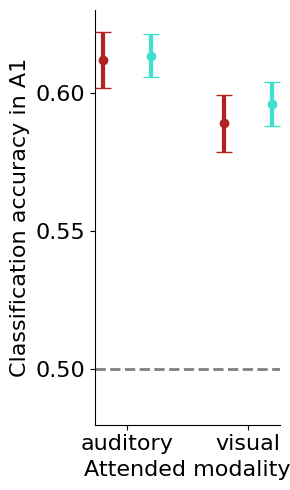

In [5]:
y = "correct"
x = "modality"
hue = "a_pred"
id = "subj"
savefig = False
errorbar_style={"capsize": 6, "elinewidth": 3, "markersize": 6}

dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
fig, ax = plt.subplots(figsize=(3, 5))
barplot_morey(dat, x, y, hue, "visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False, ax, legend=False, errorbar_style=errorbar_style, fontsize=16)
sns.despine()
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in {ROI}")
plt.xlabel("Attended modality")
plt.ylim(0.48, 0.63)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--", linewidth=2)
plt.tight_layout()

if savefig:
    plt.savefig(f"figures/MVPA/attention_pred_{ROI}.svg", dpi=300)
plt.show()

In [6]:
df["correct"].mean()

np.float64(0.6026104166666667)

In [7]:
df.groupby("modality")["correct"].mean()

modality
auditory    0.612667
visual      0.592554
Name: correct, dtype: float64

In [8]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,0.010113,1,24,0.010113,4.878311,0.036992,0.036992,0.019245,1.0
1,a_pred,0.000470,1,24,0.000470,0.299112,0.589489,0.589489,0.000912,1.0
2,modality * a_pred,0.000178,1,24,0.000178,0.069298,0.794609,0.794609,0.000346,1.0


In [7]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=dat, padjust="fdr_bh")

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,2.208690,24.0,two-sided,0.036992,NaN,NaN,1.628,0.300786
1,a_pred,-,0,1,True,True,-0.546911,24.0,two-sided,0.589489,NaN,NaN,0.242,-0.065826
2,modality * a_pred,auditory,0,1,True,True,-0.131688,24.0,two-sided,0.896329,0.896329,fdr_bh,0.213,-0.021474
3,modality * a_pred,visual,0,1,True,True,-0.535165,24.0,two-sided,0.597460,0.896329,fdr_bh,0.24,-0.098543


## Multimodal analyses

### Check interaction across ROI sizes

#### Auditory attended

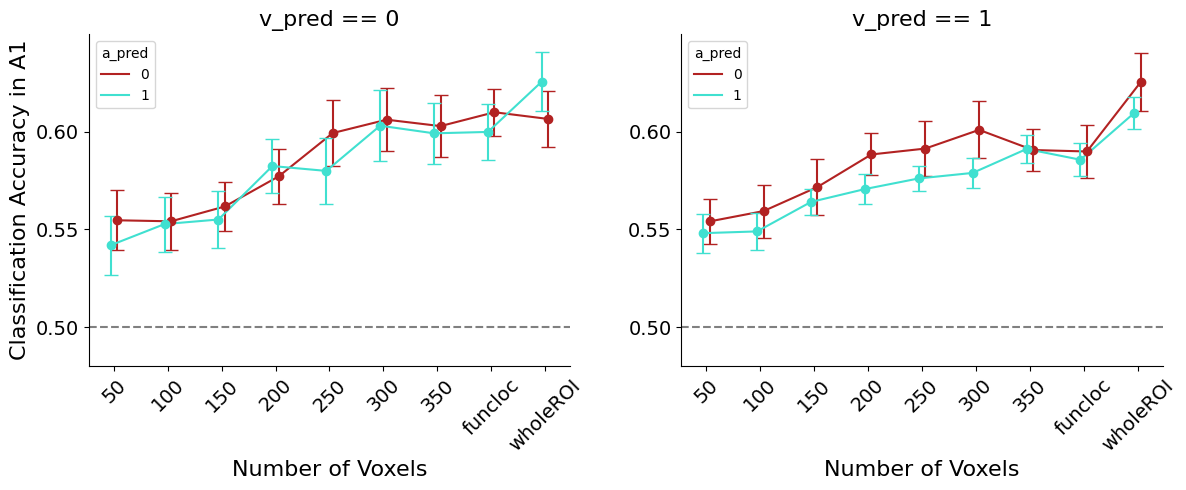

In [ ]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]
ROI = "A1"
hue = "a_pred"
col = "v_pred"
attended_modality = "auditory"
palette = ["firebrick", "turquoise"]
df_attended = plot_decoding_pred(DATA_PATH, ROI, n_voxels_list, hue, col, palette, attended_modality, error_type="wsSE", save_fig=False)

Compute stats for each ROI size, and save them

In [5]:
factors = ("v_pred", "a_pred")
alternative = "less" # sharpening specific hypothesis

with warnings.catch_warnings(): # hiding some pingouin warnings
    warnings.simplefilter("ignore", category=FutureWarning)
    anova_df, ttest_df = decoding_crossmodal_stats(df_attended, within_factors=factors, alternative=alternative)

# Customize dataframe to create tables
roi_order = ["50", "100", "150", "200", "250", "300", "350", "funcloc", "wholeROI"]

# Reorder column and sort for anova_df
anova_df["n_voxels_label"] = pd.Categorical(anova_df["n_voxels_label"], categories=roi_order, ordered=True)
anova_df = anova_df.sort_values("n_voxels_label")

# Move n_voxels_label to first column
cols = ["n_voxels_label"] + [col for col in anova_df.columns if col != "n_voxels_label"]
anova_df = anova_df[cols]

# Same for ttest_df
ttest_df["n_voxels_label"] = pd.Categorical(ttest_df["n_voxels_label"], categories=roi_order, ordered=True)
ttest_df = ttest_df.sort_values("n_voxels_label")

cols = ["n_voxels_label"] + [col for col in ttest_df.columns if col != "n_voxels_label"]
ttest_df = ttest_df[cols]

# Save ANOVA and t-test tables. Will be imported in R to generate latex tables
anova_df.reset_index().to_csv("tables/a_decoding_attended_anova.csv", index=False)
ttest_df.reset_index().to_csv("tables/a_decoding_attended_ttests.csv", index=False)

#### Visual attended

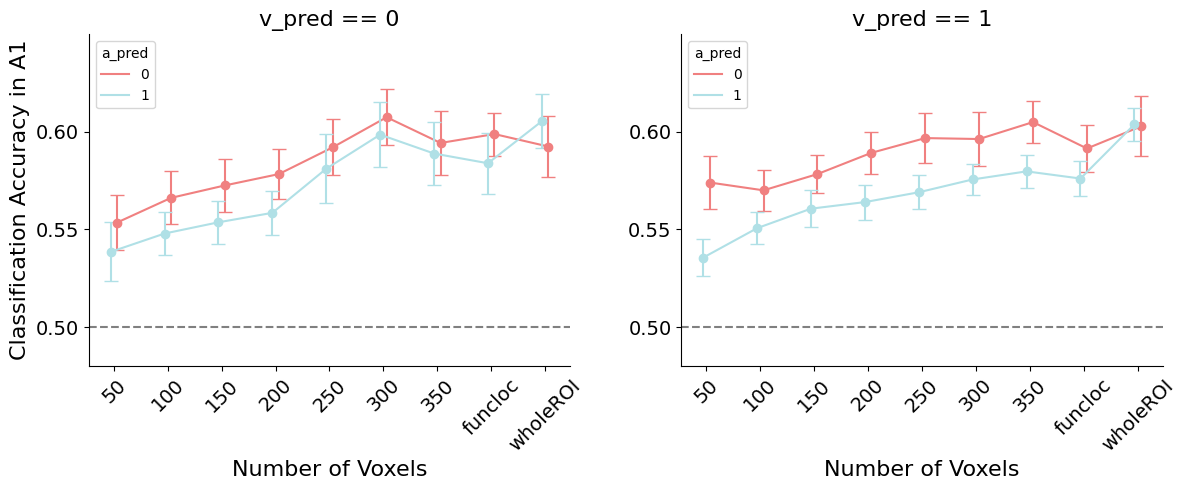

In [ ]:
ROI = "A1"
hue = "a_pred"
col = "v_pred"
attended_modality = "visual"
palette = ["lightcoral", "powderblue"]
df_unattended = plot_decoding_pred(DATA_PATH, ROI, n_voxels_list, hue, col, palette, attended_modality, error_type="wsSE", save_fig=False)

Compute stats for each ROI size, and save them

In [7]:
factors = ("v_pred", "a_pred")
alternative = "greater" # dampening specific hypothesis

with warnings.catch_warnings(): # hiding some pingouin warnings
    warnings.simplefilter("ignore", category=FutureWarning)
    anova_df, ttest_df = decoding_crossmodal_stats(df_unattended, within_factors=factors, alternative=alternative)

# Customize dataframe to create tables
roi_order = ["50", "100", "150", "200", "250", "300", "350", "funcloc", "wholeROI"]

# Reorder column and sort for anova_df
anova_df["n_voxels_label"] = pd.Categorical(anova_df["n_voxels_label"], categories=roi_order, ordered=True)
anova_df = anova_df.sort_values("n_voxels_label")

# Move n_voxels_label to first column
cols = ["n_voxels_label"] + [col for col in anova_df.columns if col != "n_voxels_label"]
anova_df = anova_df[cols]

# Same for ttest_df
ttest_df["n_voxels_label"] = pd.Categorical(ttest_df["n_voxels_label"], categories=roi_order, ordered=True)
ttest_df = ttest_df.sort_values("n_voxels_label")

cols = ["n_voxels_label"] + [col for col in ttest_df.columns if col != "n_voxels_label"]
ttest_df = ttest_df[cols]

# Save ANOVA and t-test tables. Will be imported in R to generate latex tables
anova_df.reset_index().to_csv("tables/a_decoding_unattended_anova.csv", index=False)
ttest_df.reset_index().to_csv("tables/a_decoding_unattended_ttests.csv", index=False)

### Check cross-modal effect for a specific ROI size

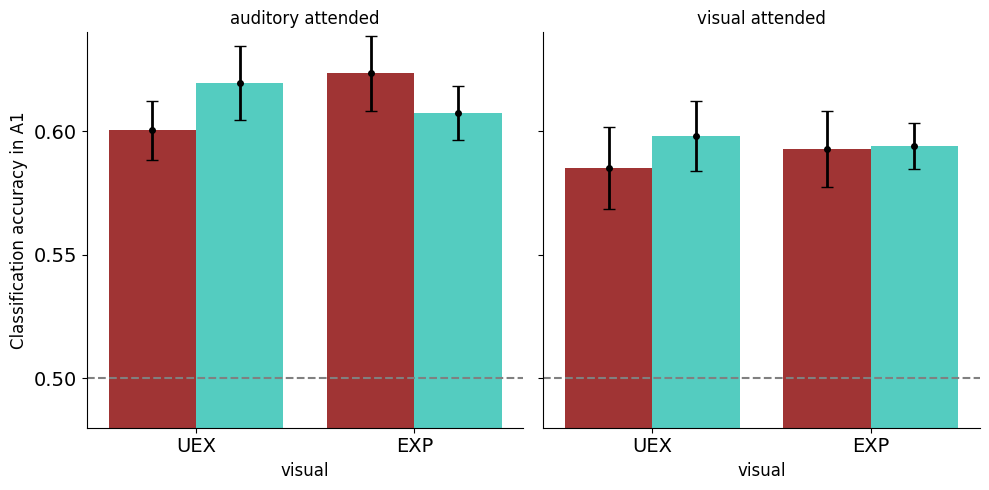

In [13]:
y = "correct"
x = "v_pred"
hue = "a_pred"
id = "subj"
ROI = "A1"
save_fig = False
ylim = (0.48, 0.64)
yticks = [0.5, 0.55, 0.6]
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[y].mean()

plot_crossmodal(
    df_grouped, y, x, hue, "visual expected", id, ROI, n_voxels, save_fig, ylim, yticks
)